## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso.


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import bootcampviztools as bt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import cross_val_score, train_test_split

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo.

**bank client data:**
1. age (numeric)
2. job: type of job (categorical)
3. marital: marital status (categorical)
4. education (categorical)
5. default: has credit in default? (binary)
6. balance: average yearly balance, in euros (numeric)
7. housing: has housing loan? (binary)
8. loan: has personal loan? (binary)

**related with the last contact:**
9. contact: contact communication type (categorical)
10. day: last contact day of the month (numeric)
11. month: last contact month of year (categorical)
12. duration: last contact duration, in seconds (numeric) ⚠️

**other attributes:**
13. campaign: number of contacts during this campaign (numeric)
14. pdays: number of days after last contact from previous campaign (-1 = never contacted)
15. previous: number of contacts before this campaign (numeric)
16. poutcome: outcome of previous marketing campaign (categorical)

> ⚠️ **NOTA SOBRE `duration`**: Esta variable introduce **data leakage**. Solo puedes conocer la duración de una llamada *después* de haberla realizado, por lo que en producción real no estaría disponible en el momento de predecir. La mantenemos para ver su impacto en métricas, pero es importante tenerla en cuenta al interpretar los resultados.


### EMPEZAMOS, PRIMER VISTAZO

In [55]:
df = pd.read_csv("./data/bank-full.csv", sep = ";")
target = "y"

In [56]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [58]:
# Análisis de "unknown" y missings
for col in df.columns:
    print(f"Para {col}, unknowns o missings:", end = " ")
    try:
        missings = df[col].value_counts()["unknown"]
        print(f"{missings}, {round(missings/len(df)*100.0, 2)}%")
    except:
        print(0)


Para age, unknowns o missings: 0
Para job, unknowns o missings: 288, 0.64%
Para marital, unknowns o missings: 0
Para education, unknowns o missings: 1857, 4.11%
Para default, unknowns o missings: 0
Para balance, unknowns o missings: 0
Para housing, unknowns o missings: 0
Para loan, unknowns o missings: 0
Para contact, unknowns o missings: 13020, 28.8%
Para day, unknowns o missings: 0
Para month, unknowns o missings: 0
Para duration, unknowns o missings: 0
Para campaign, unknowns o missings: 0
Para pdays, unknowns o missings: 0
Para previous, unknowns o missings: 0
Para poutcome, unknowns o missings: 36959, 81.75%
Para y, unknowns o missings: 0


In [59]:
df.shape

(45211, 17)

In [60]:
# Miro con más detalle las que tienen un porcentaje alto (contact y poutcome)
df.poutcome.value_counts(True)


poutcome
unknown    0.817478
failure    0.108403
other      0.040698
success    0.033421
Name: proportion, dtype: float64

*Me la quedo provisionalmente, lo que tendré que entender es el encoding*

In [61]:
df.contact.value_counts(True)

contact
cellular     0.647741
unknown      0.287983
telephone    0.064276
Name: proportion, dtype: float64

*En definitiva, las variables con "faltantes" o "unknowns" son todas categóricas, los missings los considero un valor más y veo en el bivariante qué hacer.*

#### Distribución del target

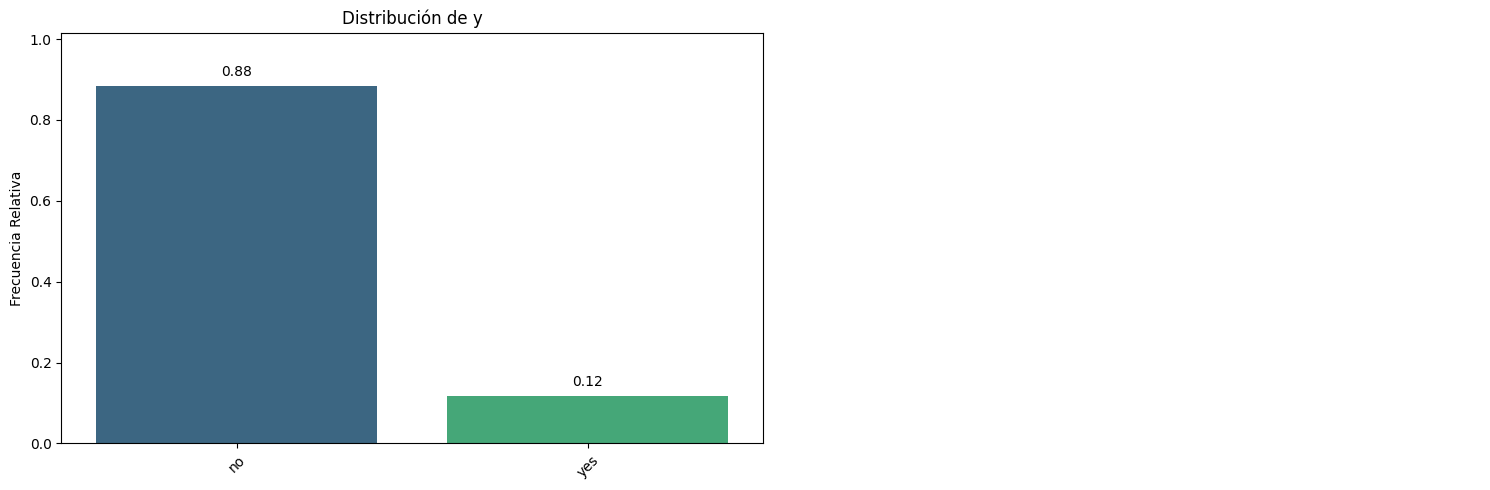

In [62]:
bt.pinta_distribucion_categoricas(df, [target], relativa=True, mostrar_valores=True)

*Esto es un ejemplo claro de target no equilibrado o desbalanceado. Under/Oversampling, hiperparámetro de `class_weight = 'balanced'`*

### TRAIN/TEST

In [63]:
# ✅ CORRECCIÓN 1: stratify=df[target]
# Con un target tan desbalanceado (~88% "no"), sin stratify arriesgamos que
# train y test tengan distribuciones del target muy distintas.
# stratify garantiza que ambos splits mantienen la misma proporción de clases.
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target])

print("Distribución en train:")
print(train_set[target].value_counts(normalize=True).round(3))
print("\nDistribución en test:")
print(test_set[target].value_counts(normalize=True).round(3))


Distribución en train:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64

Distribución en test:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64


### MINIEDA

In [64]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36168 entries, 24001 to 44229
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        36168 non-null  int64 
 1   job        36168 non-null  object
 2   marital    36168 non-null  object
 3   education  36168 non-null  object
 4   default    36168 non-null  object
 5   balance    36168 non-null  int64 
 6   housing    36168 non-null  object
 7   loan       36168 non-null  object
 8   contact    36168 non-null  object
 9   day        36168 non-null  int64 
 10  month      36168 non-null  object
 11  duration   36168 non-null  int64 
 12  campaign   36168 non-null  int64 
 13  pdays      36168 non-null  int64 
 14  previous   36168 non-null  int64 
 15  poutcome   36168 non-null  object
 16  y          36168 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.0+ MB


In [65]:
features_cat = train_set.select_dtypes(include="object").columns.to_list()
if target in features_cat:
    features_cat.remove(target)
features_cat


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [66]:
features_num = [col for col in train_set.columns if col not in features_cat and col != target]
features_num


['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

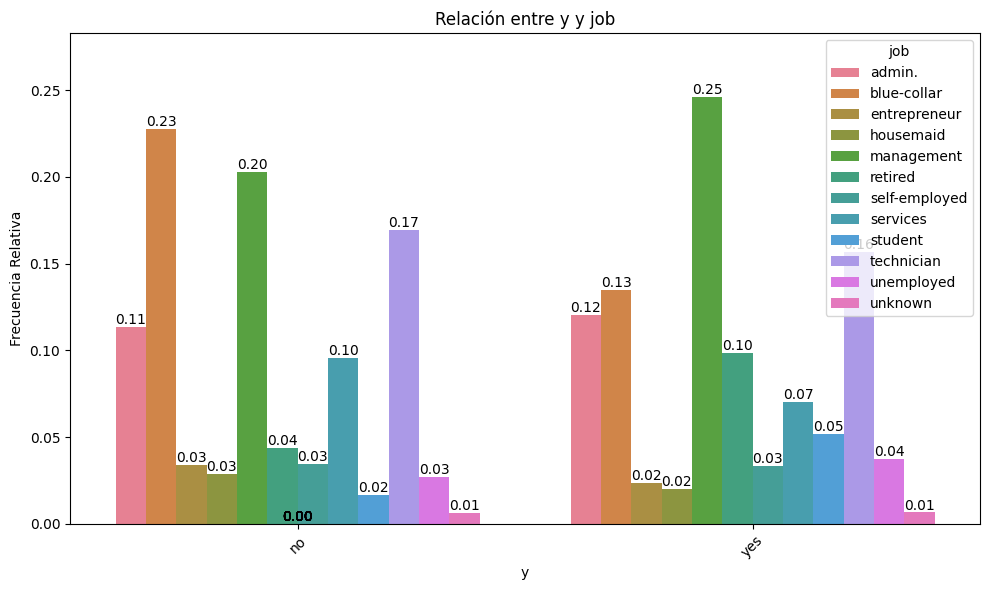

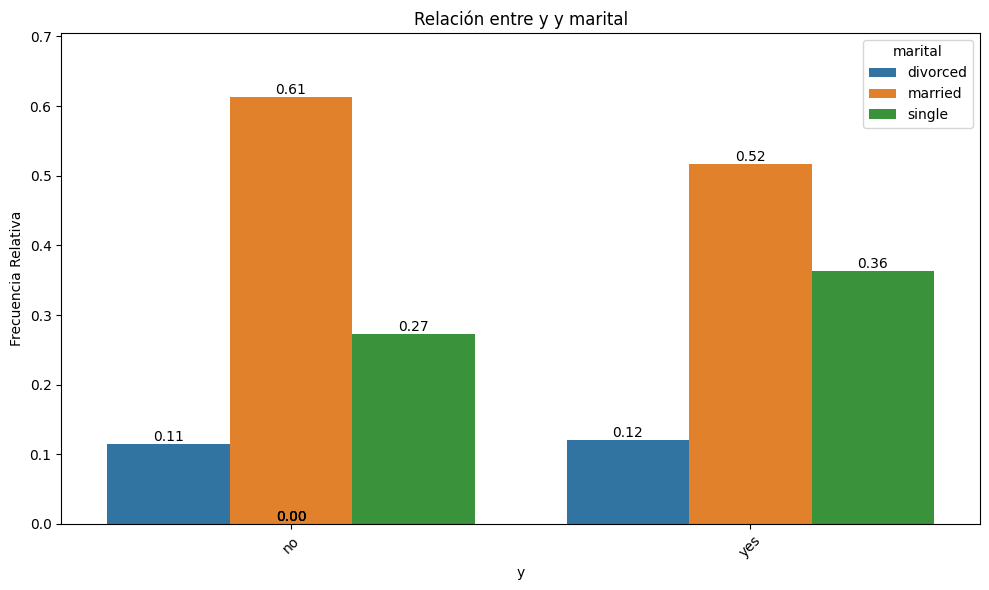

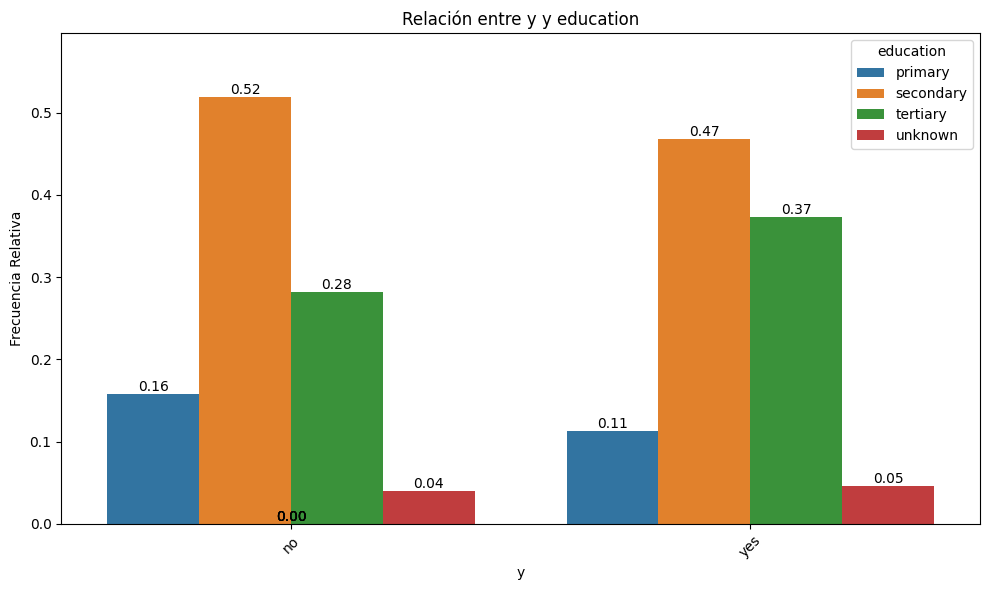

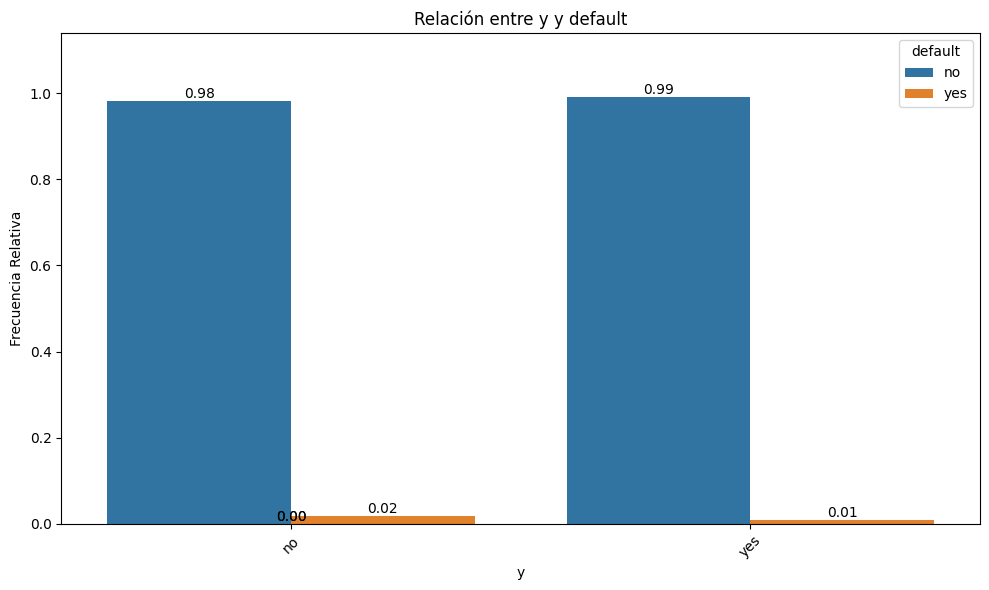

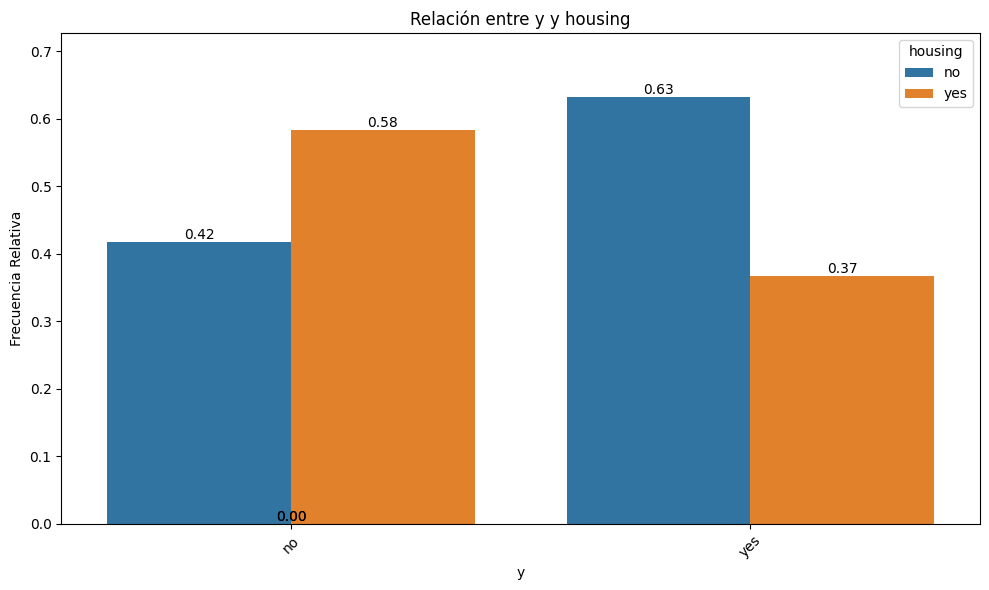

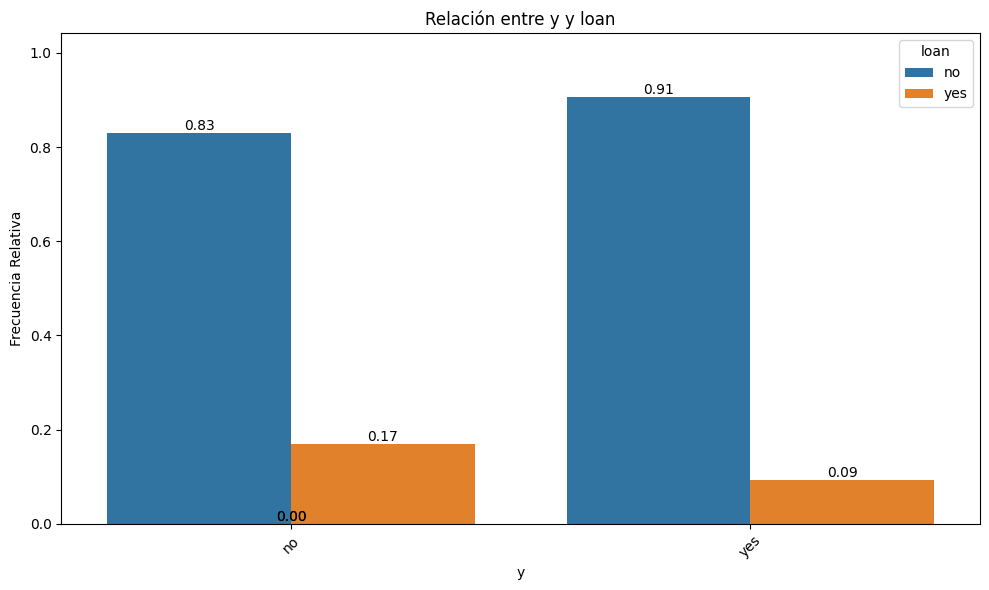

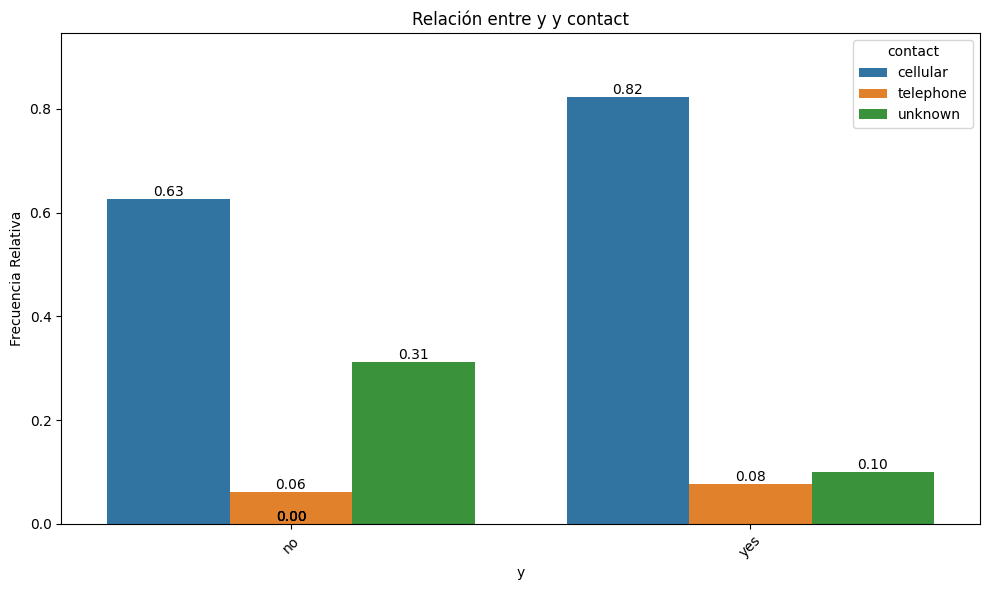

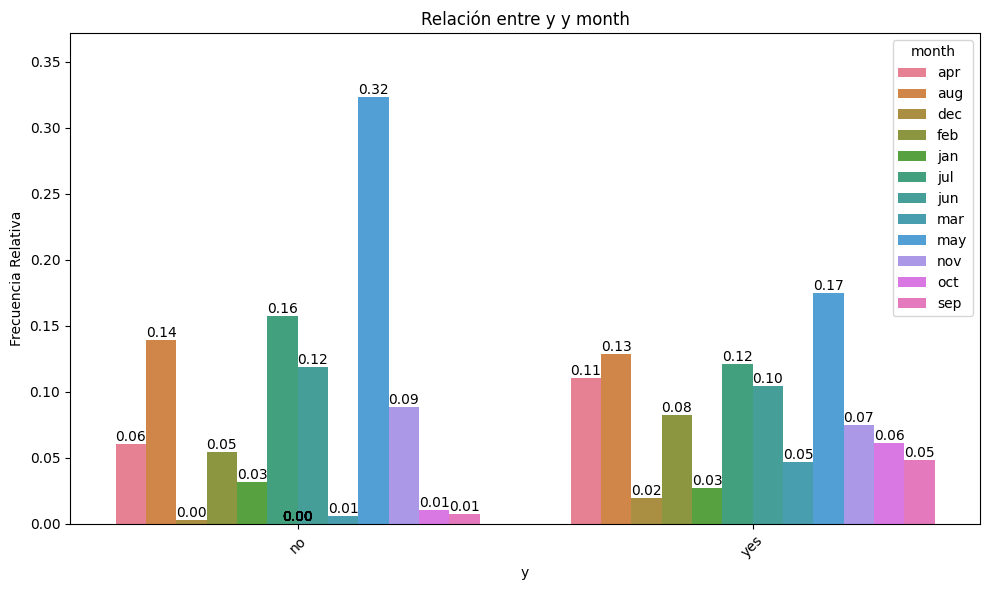

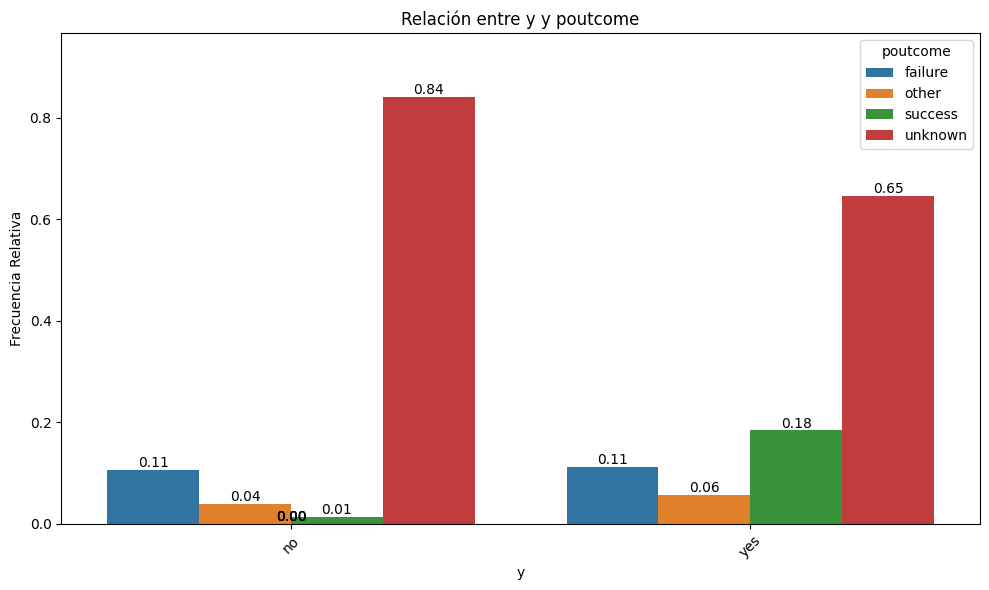

In [67]:
### Analizamos categóricas
for col in features_cat:
    bt.plot_categorical_relationship(train_set, target, col, relative_freq=True, show_values=True)


*Parece que default no discrimina y la podríamos quitar, el resto las vamos a mantener para analizar el feature importance del modelo*

In [68]:
features_cat.remove("default")

In [69]:
features_cat

['job',
 'marital',
 'education',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

### Analizamos Numéricas

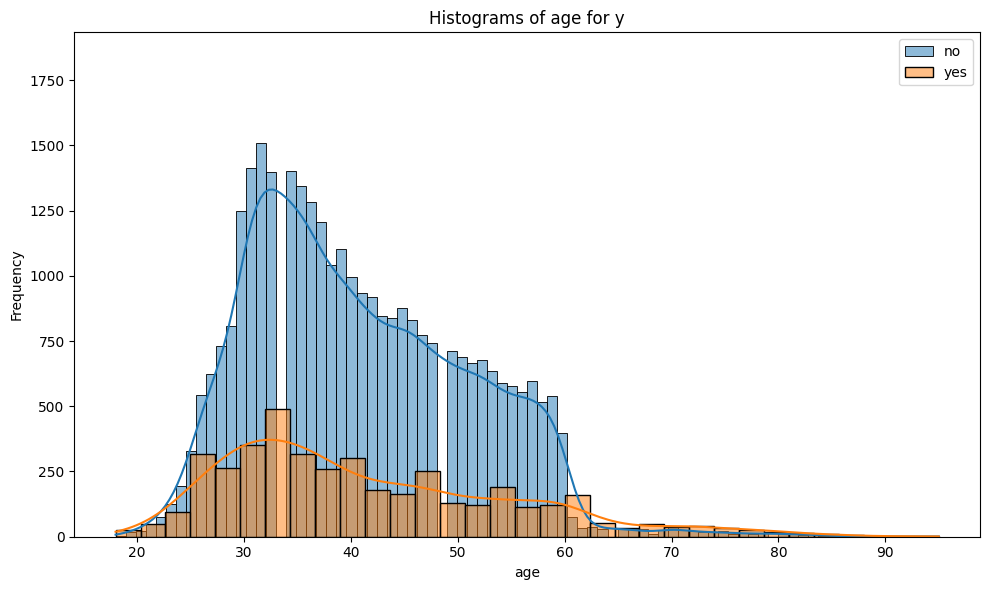

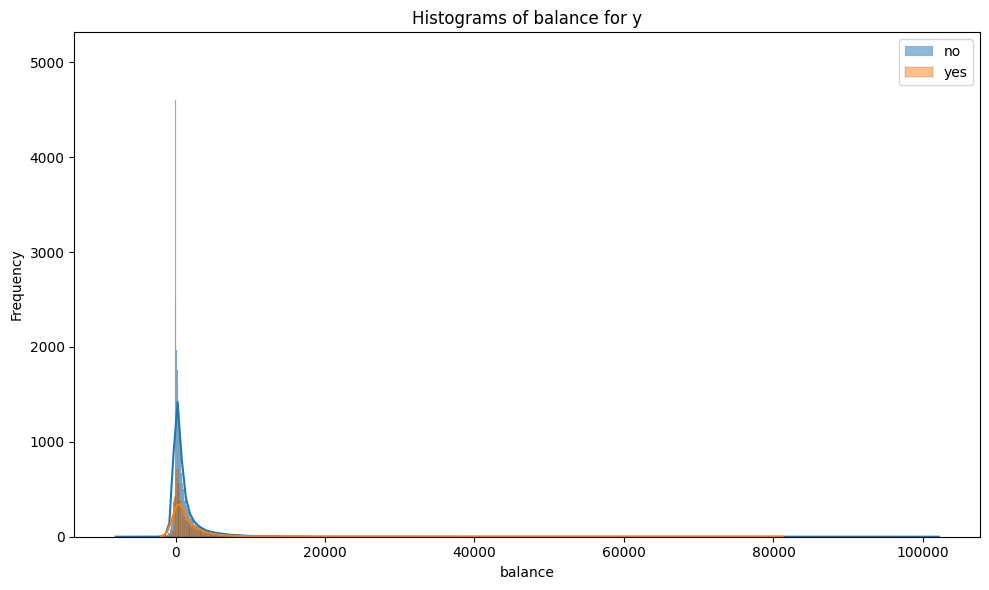

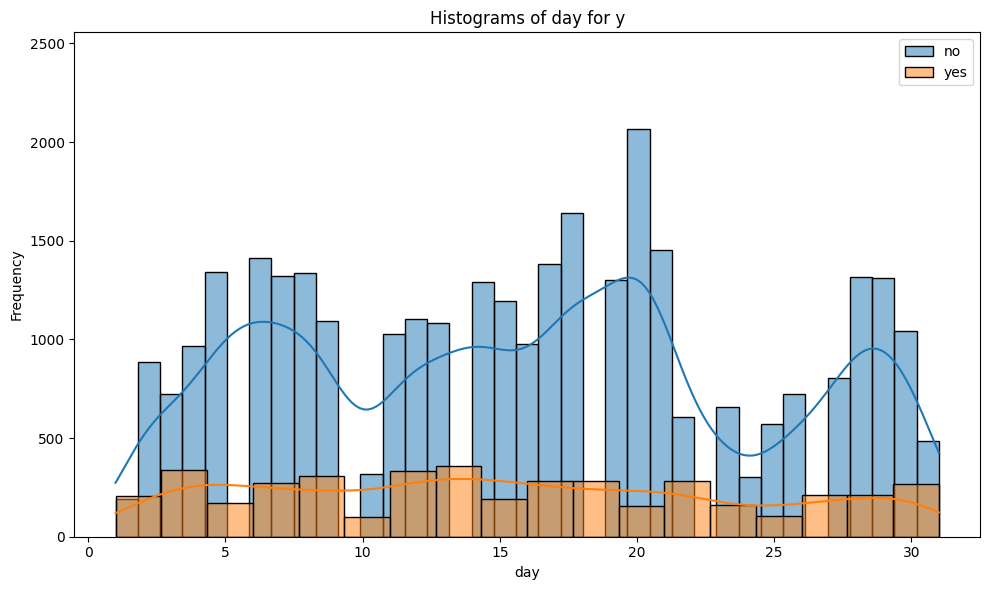

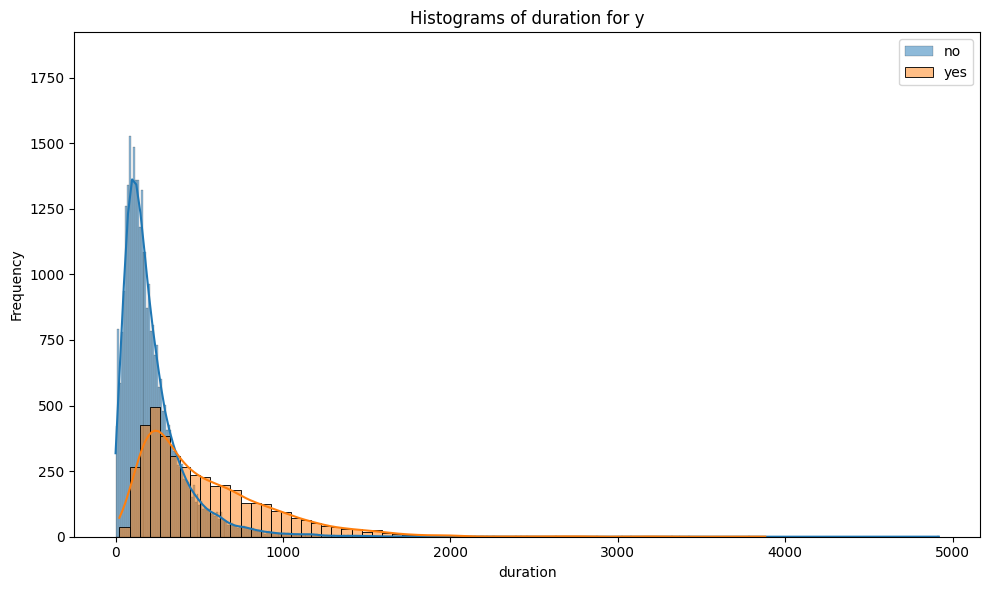

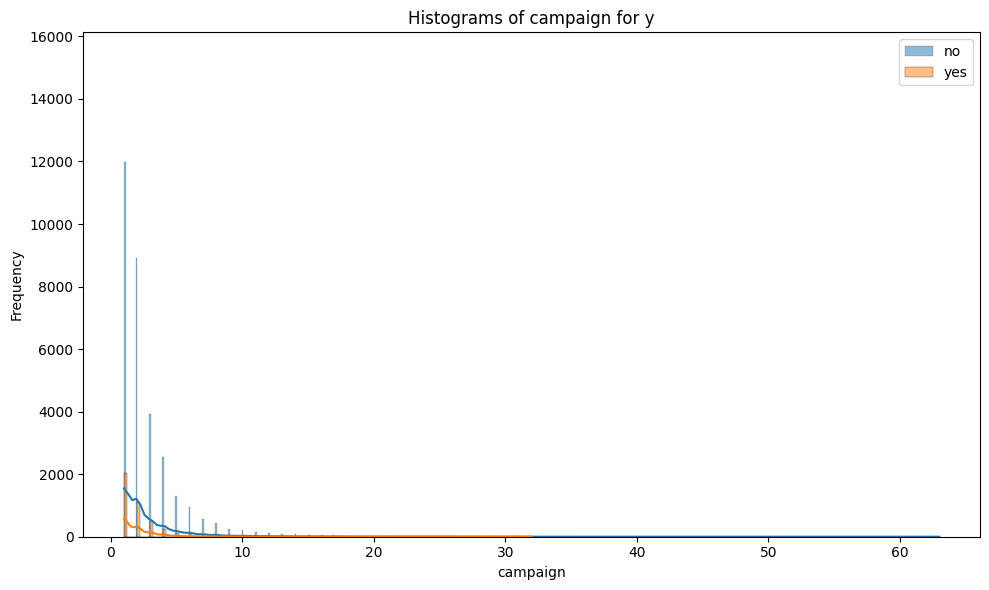

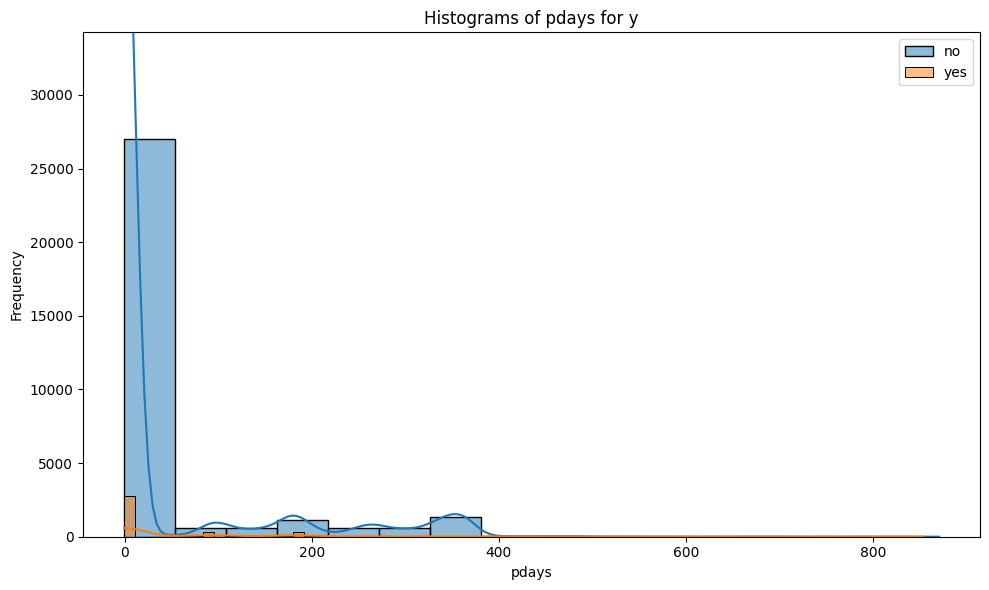

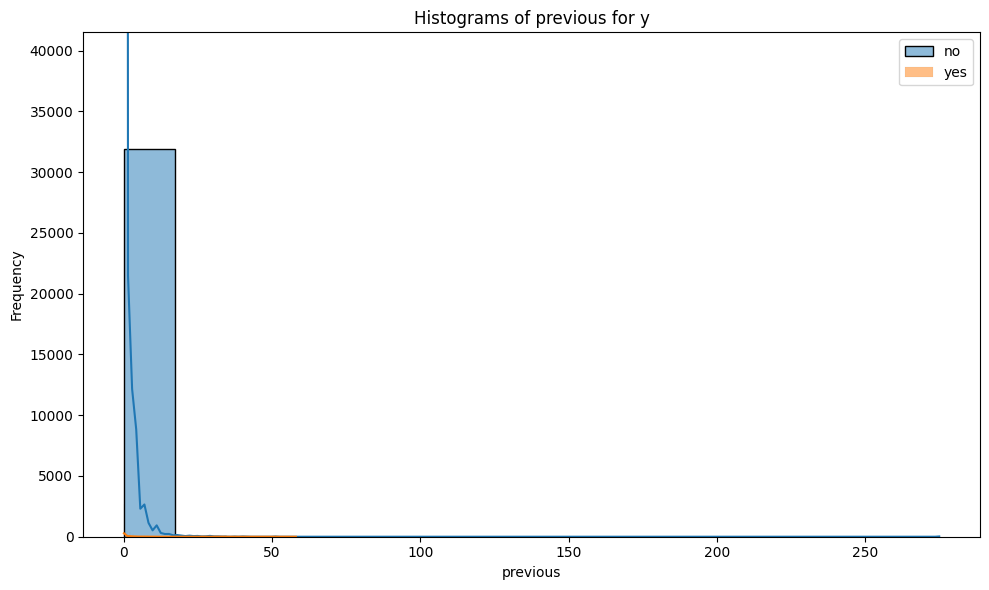

In [70]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size=2)


In [71]:
train_set["balance"].describe()

count     36168.00000
mean       1365.49342
std        3068.54350
min       -8019.00000
25%          74.00000
50%         451.00000
75%        1430.25000
max      102127.00000
Name: balance, dtype: float64

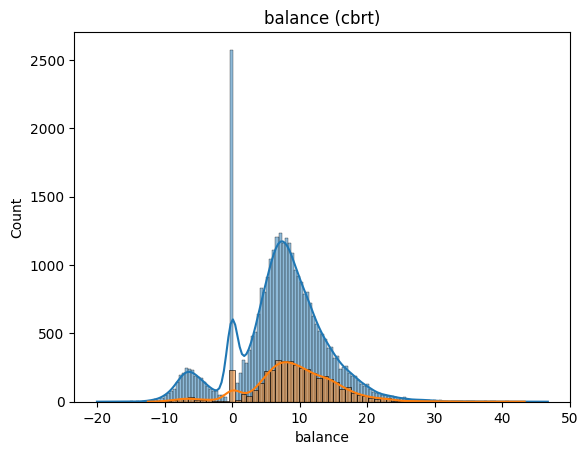

In [72]:
col = "balance"
sns.histplot(np.cbrt(train_set[col][train_set["y"] == "no"]), kde=True)
sns.histplot(np.cbrt(train_set[col][train_set["y"] == "yes"]), kde=True)
plt.title("balance (cbrt)")
plt.show()


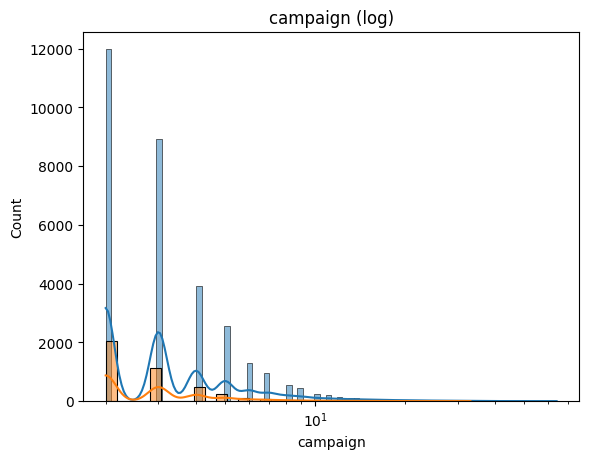

In [73]:
col = "campaign"
sns.histplot(train_set[col][train_set["y"] == "no"]+1, log_scale=10, kde=True)
sns.histplot(train_set[col][train_set["y"] == "yes"]+1, log_scale=10, kde=True)
plt.title("campaign (log)")
plt.show()


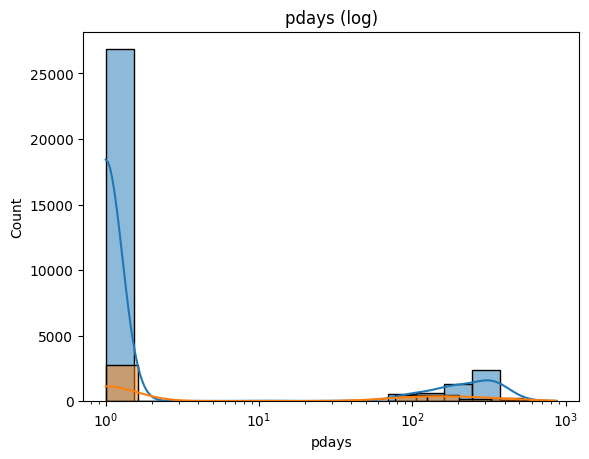

In [74]:
col = "pdays"
sns.histplot(train_set[col][train_set["y"] == "no"]+2, log_scale=10, kde=True)
sns.histplot(train_set[col][train_set["y"] == "yes"]+2, log_scale=10, kde=True)
plt.title("pdays (log)")
plt.show()


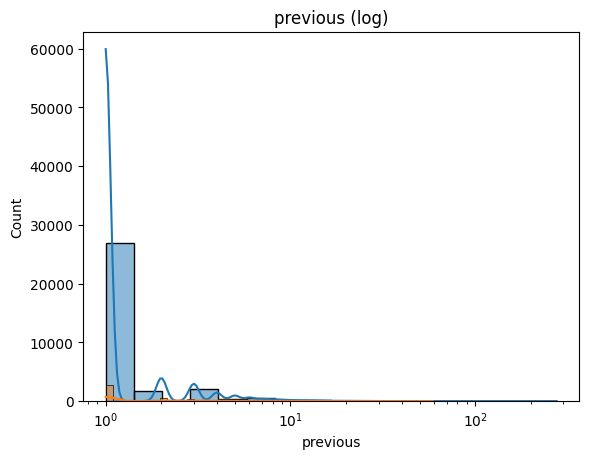

In [75]:
col = "previous"
sns.histplot(train_set[col][train_set["y"] == "no"]+1, log_scale=10, kde=True)
sns.histplot(train_set[col][train_set["y"] == "yes"]+1, log_scale=10, kde=True)
plt.title("previous (log)")
plt.show()


### Tratamiento

Categóricas:

In [76]:
train_set[features_cat].nunique()

job          12
marital       3
education     4
housing       2
loan          2
contact       3
month        12
poutcome      4
dtype: int64

Sabíamos que `housing` y `loan` son de tipo binario, por lo que las transformamos con máscaras de booleanos.
`month` es ordinal, la transformamos con mapeo usando un diccionario.
El resto se convertirán con One-hot encoding via `pd.get_dummies()`.


In [77]:
features_cat_sel = features_cat.copy()

In [78]:
train_set["housing"] = train_set["housing"] == "yes"
train_set["loan"]    = train_set["loan"]    == "yes"
test_set["housing"]  = test_set["housing"]  == "yes"
test_set["loan"]     = test_set["loan"]     == "yes"

features_cat.remove("housing")
features_cat.remove("loan")


In [79]:
month_dic = {
    "jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
    "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12
}
train_set["month"] = train_set["month"].map(month_dic)
test_set["month"]  = test_set["month"].map(month_dic)
features_cat.remove("month")


In [80]:
train_set = pd.get_dummies(train_set, columns=features_cat, dtype=int)
test_set  = pd.get_dummies(test_set,  columns=features_cat, dtype=int)


In [81]:
# ✅ CORRECCIÓN 2: check bidireccional de columnas tras get_dummies
# El original solo comprobaba train→test pero no test→train.
# Si test tuviera categorías no vistas en train, entrarían columnas silenciosas en X_test.
cols_en_train_no_en_test = train_set.columns[~train_set.columns.isin(test_set.columns)].tolist()
cols_en_test_no_en_train = test_set.columns[~test_set.columns.isin(train_set.columns)].tolist()

print("Columnas en train que NO están en test:", cols_en_train_no_en_test)
print("Columnas en test  que NO están en train:", cols_en_test_no_en_train)

# Si hubiera diferencias, alineamos:
test_set = test_set.reindex(columns=train_set.columns, fill_value=0)
print("\nDimensiones alineadas -> train:", train_set.shape, "| test:", test_set.shape)


Columnas en train que NO están en test: []
Columnas en test  que NO están en train: []

Dimensiones alineadas -> train: (36168, 38) | test: (9043, 38)


Ahora tratamos las features_num

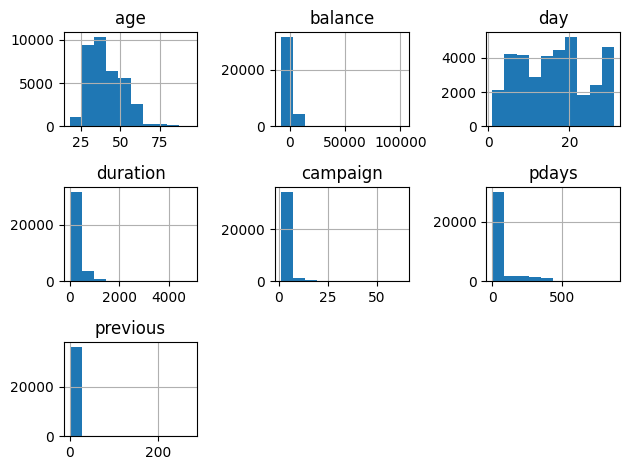

In [82]:
train_set[features_num].hist()
plt.tight_layout()


In [83]:
# pdays = -1 significa "no contactado anteriormente". Extraemos esa info como variable binaria.
train_set["contacted_before"] = train_set["pdays"] != -1
test_set["contacted_before"]  = test_set["pdays"]  != -1

train_set.contacted_before.value_counts(normalize=True)


contacted_before
False    0.817961
True     0.182039
Name: proportion, dtype: float64

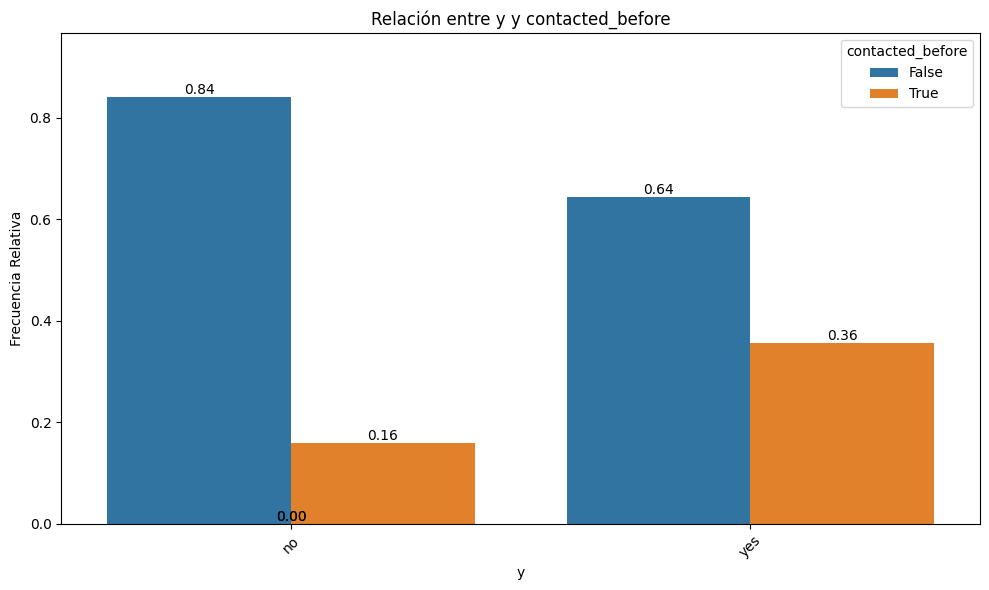

In [84]:
bt.plot_categorical_relationship(train_set, target, "contacted_before", relative_freq=True, show_values=True)


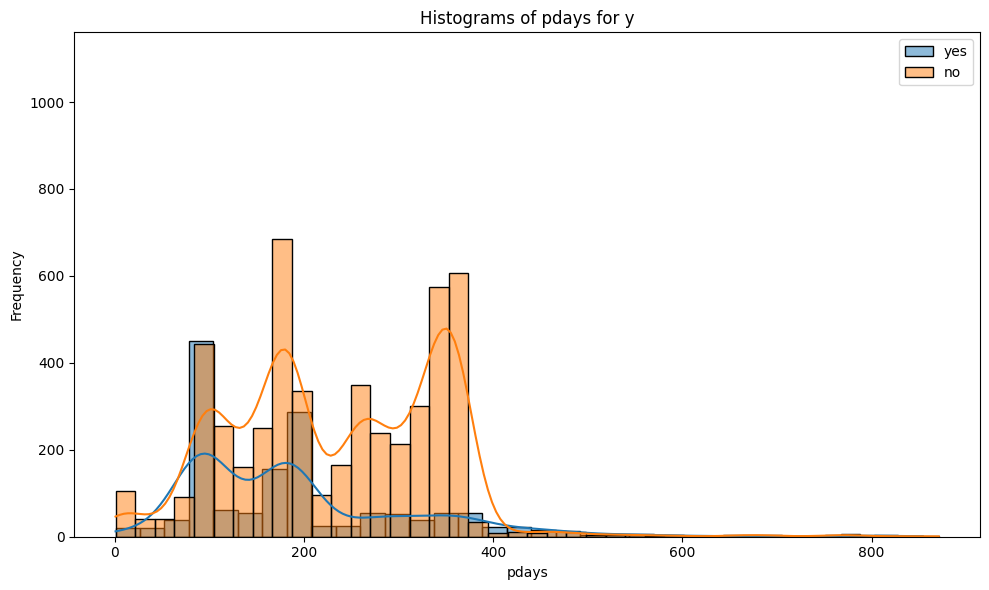

In [85]:
bt.plot_grouped_histograms(train_set[train_set.contacted_before == 1], cat_col=target, num_col="pdays", group_size=2)


In [86]:
features_cat_sel.append("contacted_before")

train_set_scaled = train_set.copy()
test_set_scaled  = test_set.copy()


#### Transformación y escalado de variables numéricas

In [87]:
# Aplicamos transformaciones para reducir la asimetría antes de escalar
train_set_scaled["balance"]  = np.cbrt(train_set_scaled["balance"])   # cbrt: admite negativos
train_set_scaled["duration"] = np.log(train_set_scaled["duration"] + 1)
train_set_scaled["campaign"] = np.log(train_set_scaled["campaign"])   # campaign >= 1 siempre
train_set_scaled["pdays"]    = np.log(train_set_scaled["pdays"] + 2)  # -1+2=1 → log(1)=0
train_set_scaled["previous"] = np.log(train_set_scaled["previous"] + 1)

test_set_scaled["balance"]   = np.cbrt(test_set_scaled["balance"])
test_set_scaled["duration"]  = np.log(test_set_scaled["duration"] + 1)
test_set_scaled["campaign"]  = np.log(test_set_scaled["campaign"])
test_set_scaled["pdays"]     = np.log(test_set_scaled["pdays"] + 2)
test_set_scaled["previous"]  = np.log(test_set_scaled["previous"] + 1)


In [88]:
# ✅ CORRECCIÓN 3: RobustScaler en lugar de StandardScaler
#
# StandardScaler usa media y desviación típica → muy sensible a outliers.
# RobustScaler usa mediana e IQR (rango intercuartílico) → mucho más robusto.
#
# Aunque ya hemos aplicado transformaciones log/cbrt, variables como `age`,
# `day` o `balance` siguen teniendo outliers residuales. RobustScaler los maneja
# mejor sin distorsionar la escala del resto de los datos.
# Es la elección más defensiva cuando no podemos garantizar que los outliers
# han desaparecido completamente tras las transformaciones.

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()  # usa mediana e IQR

train_set_scaled[features_num] = scaler.fit_transform(train_set_scaled[features_num])
test_set_scaled[features_num]  = scaler.transform(test_set_scaled[features_num])  # solo transform en test


In [89]:
train_set_scaled.describe()

,age,balance,day,month,duration,campaign,pdays,previous,job_admin.,job_blue-collar,...,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
count,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,...,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000
mean,0.126200,-0.028210,-0.014003,6.140539,-0.023733,0.012460,0.956085,0.225519,0.114493,0.216490,...,0.513188,0.292911,0.040975,0.648778,0.064062,0.287160,0.107526,0.041058,0.033317,0.818099
std,0.708472,0.930989,0.640922,2.401950,0.823374,0.648098,2.048287,0.532937,0.318414,0.411858,...,0.499833,0.455104,0.198236,0.477359,0.244867,0.452443,0.309785,0.198428,0.179465,0.385768
min,-1.400000,-3.916586,-1.153846,1.000000,-4.638201,-0.630930,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.400000,-0.490968,-0.615385,5.000000,-0.494384,-0.630930,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.600000,0.509032,0.384615,8.000000,0.505616,0.369070,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,3.733333,5.527852,1.153846,12.000000,2.946434,3.140314,6.771936,5.620401,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


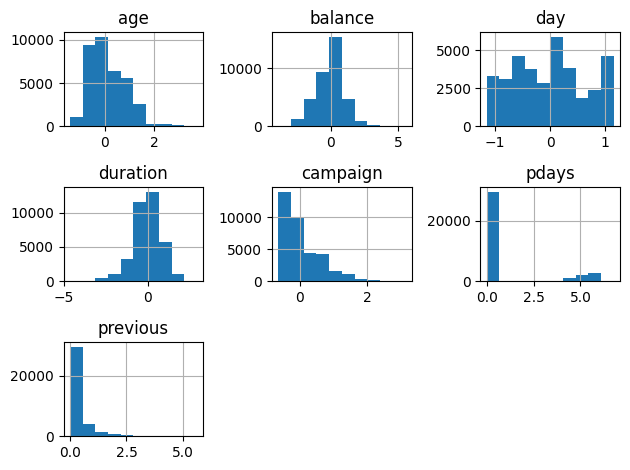

In [90]:
train_set_scaled[features_num].hist()
plt.tight_layout()


### Importamos modelos, entrenamos, creamos el baseline

In [91]:
features_cat_sel

['job',
 'marital',
 'education',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'contacted_before']

In [92]:
train_set.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'month',
       'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'poutcome_failure', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown', 'contacted_before'],
      dtype='object')

In [93]:
# ✅ CORRECCIÓN 4: typo corregido ("defintive" → "definitive")
features_encoded_cat_sel = []
for col in features_cat_sel:
    definitive_col = [col_2 for col_2 in train_set.columns if col_2.startswith(col)]
    features_encoded_cat_sel += definitive_col

features_encoded_cat_sel


['job_admin.',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_divorced',
 'marital_married',
 'marital_single',
 'education_primary',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'housing',
 'loan',
 'contact_cellular',
 'contact_telephone',
 'contact_unknown',
 'contacted_before',
 'month',
 'poutcome_failure',
 'poutcome_other',
 'poutcome_success',
 'poutcome_unknown',
 'contacted_before']

In [94]:
X_train        = train_set[features_encoded_cat_sel + features_num].copy()
X_train_scaled = train_set_scaled[features_encoded_cat_sel + features_num].copy()
y_train        = train_set[target]

X_test         = test_set[features_encoded_cat_sel + features_num].copy()
X_test_scaled  = test_set_scaled[features_encoded_cat_sel + features_num].copy()
y_test         = test_set[target]


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr_clf   = LogisticRegression(max_iter=1000)
tree_clf = DecisionTreeClassifier(random_state=42)  # sin límite → sobreajusta, lo veremos

lr_clf.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [96]:
print("--- REGRESIÓN LOGÍSTICA (train) ---")
print(classification_report(y_train, lr_clf.predict(X_train_scaled)))

--- REGRESIÓN LOGÍSTICA (train) ---
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     31937
         yes       0.64      0.33      0.44      4231

    accuracy                           0.90     36168
   macro avg       0.78      0.65      0.69     36168
weighted avg       0.88      0.90      0.89     36168



In [97]:
print("--- REGRESIÓN LOGÍSTICA (test) ---")
print(classification_report(y_test, lr_clf.predict(X_test_scaled)))

--- REGRESIÓN LOGÍSTICA (test) ---
              precision    recall  f1-score   support

          no       0.92      0.98      0.94      7985
         yes       0.63      0.32      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



In [98]:
# ✅ CORRECCIÓN 5: comparación justa mediante cross_val_score
# El árbol se va a tunear con GridSearchCV (5 folds), así que para compararlo
# con la regresión logística de forma justa, evaluamos ambos con CV sobre train.
# Comparar LR en test con árbol tuneado en CV sería comparar peras con manzanas.

cv_scores_lr = cross_val_score(lr_clf, X_train_scaled, y_train,
                               cv=5, scoring="balanced_accuracy")
print(f"LR   | balanced_accuracy CV (5-fold): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")


LR   | balanced_accuracy CV (5-fold): 0.6521 ± 0.0065


In [99]:
tree_clf.fit(X_train, y_train)
print("--- ÁRBOL SIN TUNEAR (train) — veremos overfitting ---")
print(classification_report(y_train, tree_clf.predict(X_train)))


--- ÁRBOL SIN TUNEAR (train) — veremos overfitting ---
              precision    recall  f1-score   support

          no       1.00      1.00      1.00     31937
         yes       1.00      1.00      1.00      4231

    accuracy                           1.00     36168
   macro avg       1.00      1.00      1.00     36168
weighted avg       1.00      1.00      1.00     36168



In [100]:
print("--- ÁRBOL SIN TUNEAR (test) ---")
print(classification_report(y_test, tree_clf.predict(X_test)))


--- ÁRBOL SIN TUNEAR (test) ---
              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7985
         yes       0.48      0.49      0.48      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043



In [101]:
from sklearn.model_selection import GridSearchCV

# ✅ CORRECCIÓN 6: grid más completo en max_depth
# El original saltaba de 2 a 8 directamente, dejando fuera el rango 3–7
# que suele contener los mejores árboles para este tipo de problema.
param_grid = {
    "max_depth":        [2, 3, 5, 7, 10],
    "min_samples_leaf": [1, 10, 20, 100],
    "max_features":     ["sqrt", "log2", None],
    "class_weight":     ["balanced", None]
}

tree_clf  = DecisionTreeClassifier(random_state=42)
tree_grid = GridSearchCV(tree_clf,
                         param_grid=param_grid,
                         cv=5,
                         scoring="balanced_accuracy")  # adecuado para clases desbalanceadas

tree_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [102]:
tree_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 20}

In [103]:
tree_grid.best_score_

0.8399973206474597

In [104]:
# ✅ Comparación justa: árbol tuneado vs LR con el mismo protocolo de evaluación
print(f"LR   | balanced_accuracy CV (5-fold): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"Tree | balanced_accuracy CV (5-fold): {tree_grid.best_score_:.4f}")


LR   | balanced_accuracy CV (5-fold): 0.6521 ± 0.0065
Tree | balanced_accuracy CV (5-fold): 0.8400


### Evaluación final contra test

In [105]:
y_pred_train = tree_grid.best_estimator_.predict(X_train)
print("--- MEJOR ÁRBOL (train) ---")
print(classification_report(y_train, y_pred_train))


--- MEJOR ÁRBOL (train) ---
              precision    recall  f1-score   support

          no       0.99      0.82      0.89     31937
         yes       0.40      0.93      0.56      4231

    accuracy                           0.83     36168
   macro avg       0.70      0.87      0.73     36168
weighted avg       0.92      0.83      0.86     36168



In [106]:
y_pred_test = tree_grid.best_estimator_.predict(X_test)
print("--- MEJOR ÁRBOL (test) ---")
print(classification_report(y_test, y_pred_test))


--- MEJOR ÁRBOL (test) ---
              precision    recall  f1-score   support

          no       0.98      0.81      0.89      7985
         yes       0.37      0.86      0.52      1058

    accuracy                           0.82      9043
   macro avg       0.68      0.83      0.70      9043
weighted avg       0.91      0.82      0.84      9043



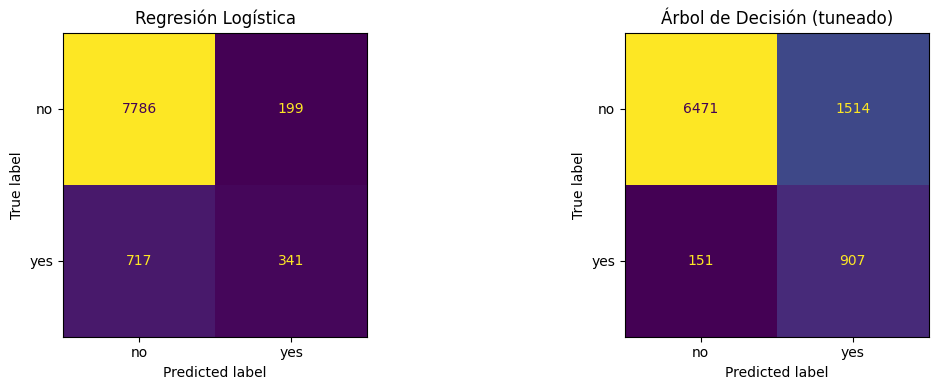

In [107]:
# ✅ CORRECCIÓN 7: usamos ConfusionMatrixDisplay (importado pero nunca usado en el original)
# Con clases desbalanceadas la matriz de confusión es clave: muestra exactamente
# cuántos "yes" estamos detectando y cuántos se nos escapan (falsos negativos).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(lr_clf, X_test_scaled, y_test,
                                      ax=axes[0], colorbar=False)
axes[0].set_title("Regresión Logística")

ConfusionMatrixDisplay.from_estimator(tree_grid.best_estimator_, X_test, y_test,
                                      ax=axes[1], colorbar=False)
axes[1].set_title("Árbol de Decisión (tuneado)")

plt.tight_layout()
plt.show()


In [108]:
df_feat_importance = pd.DataFrame({
    "features":    tree_grid.best_estimator_.feature_names_in_,
    "importancia": tree_grid.best_estimator_.feature_importances_
}).sort_values("importancia", ascending=False)

df_feat_importance


,features,importancia
34,duration,0.439797
25,month,0.142106
28,poutcome_success,0.135345
23,contact_unknown,0.082471
33,day,0.078268
19,housing,0.041304
32,balance,0.017459
31,age,0.016556
36,pdays,0.013418
20,loan,0.008651


#### EXTRA: Selección de features por feature importance

> ⚠️ **Nota metodológica**: Las features se seleccionan en base al modelo entrenado sobre X_train.
> Esto introduce un sesgo de selección sutil si el criterio de corte se elige mirando el test.
> Para hacerlo completamente correcto, este paso debería integrarse dentro del pipeline de CV
> o validarse sobre un holdout independiente. Aquí lo hacemos como ejercicio exploratorio.


In [109]:
num_features = 10
new_features_sel = df_feat_importance.iloc[:num_features]["features"].to_list()
new_features_sel


['duration',
 'month',
 'poutcome_success',
 'contact_unknown',
 'day',
 'housing',
 'balance',
 'age',
 'pdays',
 'loan']

In [110]:
X_train_sel        = train_set[new_features_sel].copy()
X_train_scaled_sel = train_set_scaled[new_features_sel].copy()
X_test_sel         = test_set[new_features_sel].copy()
X_test_scaled_sel  = test_set_scaled[new_features_sel].copy()


In [111]:
lr_clf2 = LogisticRegression(max_iter=1000)
lr_clf2.fit(X_train_scaled_sel, y_train)
print("--- LR con top features (test) ---")
print(classification_report(y_test, lr_clf2.predict(X_test_scaled_sel)))


--- LR con top features (test) ---
              precision    recall  f1-score   support

          no       0.92      0.98      0.95      7985
         yes       0.65      0.32      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



In [112]:
param_grid = {
    "max_depth":        [2, 3, 5, 7, 10],
    "min_samples_leaf": [1, 10, 20, 100],
    "max_features":     ["sqrt", "log2", None],
    "class_weight":     ["balanced", None]
}

tree_clf2   = DecisionTreeClassifier(random_state=42)
tree_grid2  = GridSearchCV(tree_clf2, param_grid=param_grid, cv=5, scoring="balanced_accuracy")
tree_grid2.fit(X_train_sel, y_train)

print(tree_grid2.best_params_)
print(f"best_score CV: {tree_grid2.best_score_:.4f}")


{'class_weight': 'balanced', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 20}
best_score CV: 0.8413


In [113]:
print("--- ÁRBOL con top features (test) ---")
print(classification_report(y_test, tree_grid2.best_estimator_.predict(X_test_sel)))


--- ÁRBOL con top features (test) ---
              precision    recall  f1-score   support

          no       0.98      0.80      0.88      7985
         yes       0.37      0.87      0.52      1058

    accuracy                           0.81      9043
   macro avg       0.67      0.83      0.70      9043
weighted avg       0.91      0.81      0.84      9043



En conclusión, si reentrenamos nuestros modelos con solo las 10 features más importantes vemos que sus métricas siguen siendo prácticamente iguales.

Prueba a modificar `num_features` para ver en qué momento el rendimiento empieza a degradarse significativamente.
